Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Upload Extracted Dataset File

In [2]:
from google.colab import files
uploaded = files.upload()

Saving spambase.data to spambase.data


Check Uploaded File Name

In [4]:
import os
print(os.listdir())

['.config', 'spambase.data', 'sample_data']


Load Dataset

In [6]:
data = pd.read_csv("spambase.data", header=None)

print(data.head())

     0     1     2    3     4     5     6     7     8     9   ...    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

      49   50     51     52     53     54   55    56  57  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278   1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028   1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259   1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191   1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191   1  

[5 rows x 58 columns]


Check Dataset Shape

In [7]:
print(data.shape)

(4601, 58)


Separate Features + Target

In [9]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print(X.shape)
print(y.shape)

(4601, 57)
(4601,)


Split Train/Test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Standardize Data

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train KNN

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

KNN Result

In [18]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.8935939196525515
[[494  37]
 [ 61 329]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       531
           1       0.90      0.84      0.87       390

    accuracy                           0.89       921
   macro avg       0.89      0.89      0.89       921
weighted avg       0.89      0.89      0.89       921



Train Naïve Bayes

In [20]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

Naïve Bayes Result

In [21]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(confusion_matrix(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8219326818675353
[[391 140]
 [ 24 366]]
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       531
           1       0.72      0.94      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



Compare Both Results Clearly

In [22]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

KNN Accuracy: 0.8935939196525515
Naive Bayes Accuracy: 0.8219326818675353


Better Result Table

In [23]:
results = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

print(results)

         Model  Accuracy
0          KNN  0.893594
1  Naive Bayes  0.821933


Confusion Matrix Visualization

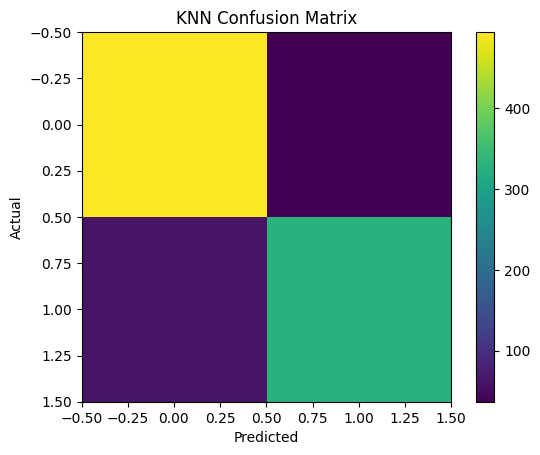

In [24]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn_pred)

plt.imshow(cm)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

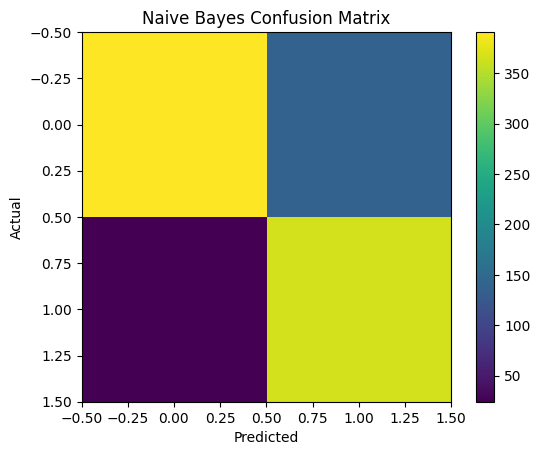

In [25]:
cm = confusion_matrix(y_test, nb_pred)

plt.imshow(cm)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [26]:
for k in range(1,11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print("K =", k, "Accuracy =", accuracy_score(y_test, pred))

K = 1 Accuracy = 0.8935939196525515
K = 2 Accuracy = 0.8783930510314875
K = 3 Accuracy = 0.8914223669923995
K = 4 Accuracy = 0.8849077090119435
K = 5 Accuracy = 0.8935939196525515
K = 6 Accuracy = 0.8892508143322475
K = 7 Accuracy = 0.8946796959826275
K = 8 Accuracy = 0.8838219326818675
K = 9 Accuracy = 0.8892508143322475
K = 10 Accuracy = 0.8849077090119435
